# Symulator tomografu

Kod testowy

Test wzorów

In [2]:
# Importy

import utils
import matplotlib.pyplot as plt
import numpy as np
from skimage.data import shepp_logan_phantom
from skimage.transform import resize
import imageio.v2 as iio
import datetime

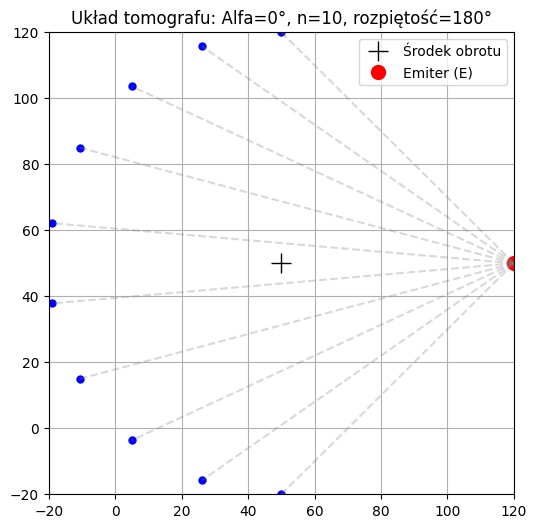

In [3]:
# --- PARAMETRY TESTOWE ---
wymiar_obrazka = 100 # Zakładamy, że nasz obrazek będzie miał 100x100 pikseli
srodek = wymiar_obrazka / 2
# Promień musi być na tyle duży, żeby czujniki "latały" dookoła obrazka (poza nim)
promien = wymiar_obrazka * 0.7 

kat_alfa = 0        # Zaczynamy od kąta 0 stopni
liczba_detektorow = 10  
rozpietosc = 180 

emiter, detektory = utils.wyznacz_pozycje_czujnikow(kat_alfa, liczba_detektorow, rozpietosc, promien, srodek, srodek)

# --- RYSOWANIE WYNIKÓW ---
plt.figure(figsize=(6, 6))

# Rysujemy środek układu (środek naszego przyszłego obrazka)
plt.plot(srodek, srodek, 'k+', markersize=15, label="Środek obrotu")

# Rysujemy Emiter (jako czerwoną kropkę)
plt.plot(emiter[0], emiter[1], 'ro', markersize=10, label="Emiter (E)")

# Rysujemy Detektory (jako niebieskie kropki)
for d in detektory:
    plt.plot(d[0], d[1], 'bo', markersize=5)
    # Rysujemy też promienie (linie od emitera do detektorów)
    plt.plot([emiter[0], d[0]], [emiter[1], d[1]], 'gray', alpha=0.3, linestyle='--')

# Ograniczamy osie wykresu dla lepszej widoczności
plt.xlim(-20, wymiar_obrazka + 20)
plt.ylim(-20, wymiar_obrazka + 20)
plt.legend()
plt.title(f"Układ tomografu: Alfa={kat_alfa}°, n={liczba_detektorow}, rozpiętość={rozpietosc}°")
plt.grid(True)
plt.show()

Chyba działa

In [4]:


image = iio.imread('./tomograf-obrazy//CT_ScoutView-large.jpg', mode='L')  
image = resize(image, (100, 100))
wymiar_y, wymiar_x = image.shape

liczba_detektorow = 180 
liczba_skanow = 180      # Ile razy emiter "błyśnie" podczas obrotu
rozpietosc = 180         # Szerokość wachlarza w stopniach
delta_alfa = 360 / liczba_skanow # Krok obrotu, tutaj: 2 stopnie

srodek_x = wymiar_x / 2
srodek_y = wymiar_y / 2
promien = max(wymiar_x, wymiar_y) * 0.7

sinogram = np.zeros((liczba_detektorow, liczba_skanow))

for skan in range(liczba_skanow):
    aktualny_kat = skan * delta_alfa

    emiter, detektory = utils.wyznacz_pozycje_czujnikow(aktualny_kat, liczba_detektorow, rozpietosc, promien, srodek_x, srodek_y)

    for i, detektor in enumerate(detektory):
        x0, y0 = int(emiter[0]), int(emiter[1])
        x1, y1 = int(detektor[0]), int(detektor[1])

        linia_pikseli = utils.bresenham(x0, y0, x1, y1)

        suma_jasnosci = 0

        for piksel in linia_pikseli:
            x, y = piksel
            if 0 <= x < wymiar_x and 0 <= y < wymiar_y:
                suma_jasnosci += image[x, y]

        sinogram[i, skan] = suma_jasnosci


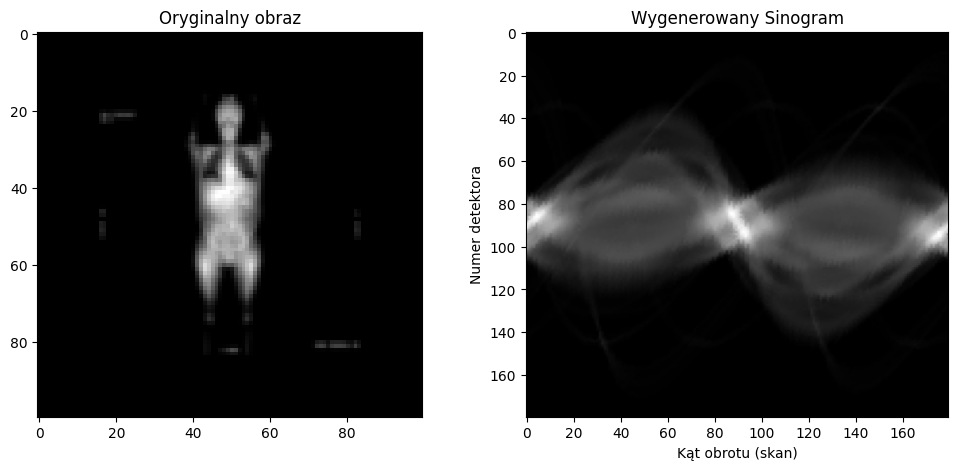

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.imshow(image, cmap='gray')
ax1.set_title("Oryginalny obraz")

ax2.imshow(sinogram, cmap='gray', aspect='auto')
ax2.set_title("Wygenerowany Sinogram")
ax2.set_xlabel("Kąt obrotu (skan)")
ax2.set_ylabel("Numer detektora")

plt.show()

Rekonstrukcja obrazu - odwrotna transformata Radona

In [6]:
rekonstruowany_obraz = np.zeros((wymiar_x, wymiar_y))

for skan in range(liczba_skanow):
    aktualny_kat = skan * delta_alfa

    emiter, detektory = utils.wyznacz_pozycje_czujnikow(aktualny_kat, liczba_detektorow, rozpietosc, promien, srodek_x, srodek_y)

    for i, detektor in enumerate(detektory):
        x0, y0 = int(emiter[0]), int(emiter[1])
        x1, y1 = int(detektor[0]), int(detektor[1])

        linia_pikseli = utils.bresenham(x0, y0, x1, y1)

        for piksel in linia_pikseli:
            x, y = piksel
            if 0 <= x < wymiar_x and 0 <= y < wymiar_y:
                rekonstruowany_obraz[x, y] += sinogram[i, skan]

Normalizacja

Text(0.5, 1.0, 'Rekonstruowany obraz')

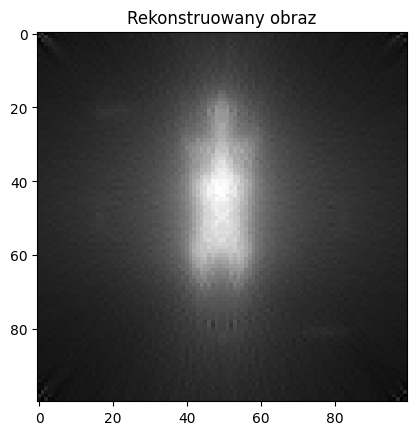

In [7]:
max_val = np.max(rekonstruowany_obraz)

if max_val > 0:
    rekonstruowany_obraz = rekonstruowany_obraz / max_val
     
plt.imshow(rekonstruowany_obraz, cmap='gray')
plt.title("Rekonstruowany obraz")

Filtrowanie -> **Do poprawy bo na niektórych obrazach nie działa i dodać mse**

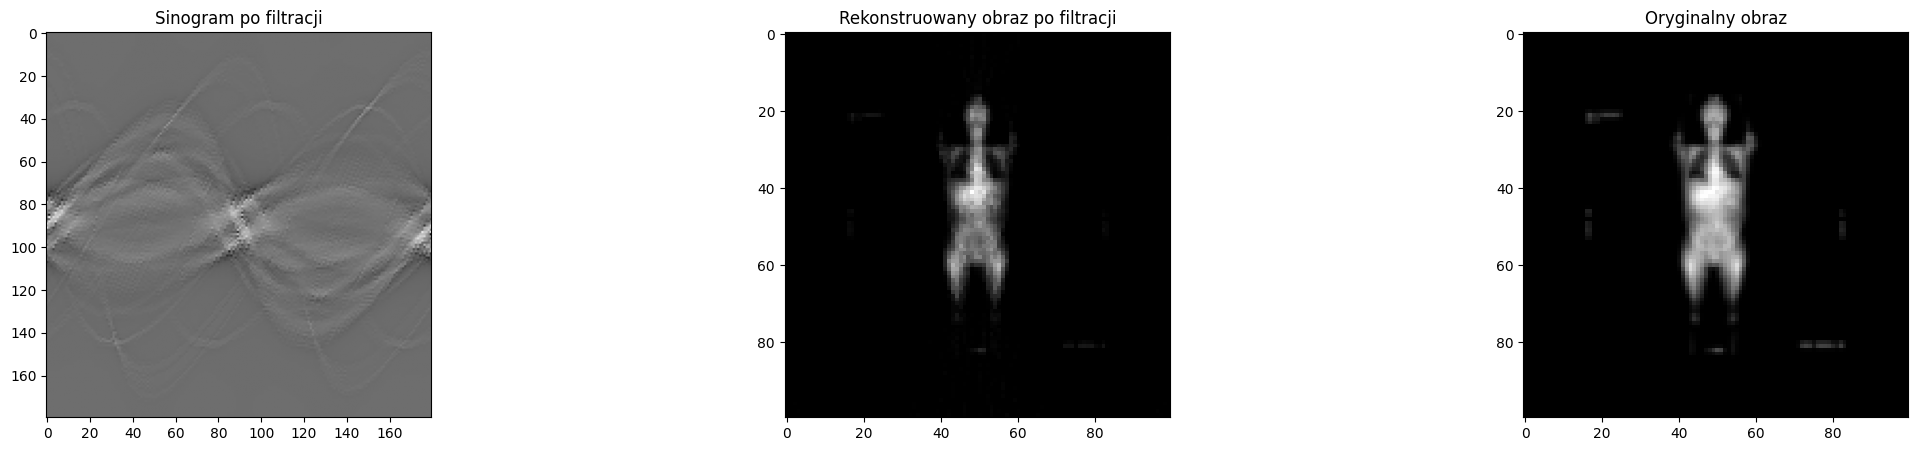

In [8]:
sinogram_rekonstruowany = utils.filtruj_sinogram(sinogram)

rekonstruowany_obraz_filtrowany = np.zeros((wymiar_x, wymiar_y))
for skan in range(liczba_skanow):
    aktualny_kat = skan * delta_alfa

    emiter, detektory = utils.wyznacz_pozycje_czujnikow(aktualny_kat, liczba_detektorow, rozpietosc, promien, srodek_x, srodek_y)

    for i, detektor in enumerate(detektory):
        x0, y0 = int(emiter[0]), int(emiter[1])
        x1, y1 = int(detektor[0]), int(detektor[1])

        linia_pikseli = utils.bresenham(x0, y0, x1, y1)

        for piksel in linia_pikseli:
            x, y = piksel
            if 0 <= x < wymiar_x and 0 <= y < wymiar_y:
                rekonstruowany_obraz_filtrowany[x, y] += sinogram_rekonstruowany[i, skan]

# Normalizacja
rekonstruowany_obraz_filtrowany[rekonstruowany_obraz_filtrowany < 0] = 0

max_val_filtrowany = np.max(rekonstruowany_obraz_filtrowany)
if max_val_filtrowany > 0:
    rekonstruowany_obraz_filtrowany = rekonstruowany_obraz_filtrowany / max_val_filtrowany

rekonstruowany_obraz_filtrowany = rekonstruowany_obraz_filtrowany ** 1.5 

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(27, 5))
ax1.imshow(sinogram_rekonstruowany, cmap='gray')
ax1.set_title("Sinogram po filtracji")
ax2.imshow(rekonstruowany_obraz_filtrowany, cmap='gray')
ax2.set_title("Rekonstruowany obraz po filtracji")
ax3.imshow(image, cmap='gray')
ax3.set_title("Oryginalny obraz")
plt.show()

Pokazanie obrazu w formacie DICOM

C:\Users\krzys\AppData\Roaming\Python\Python313\site-packages\pydicom\valuerep.py:440: UserWarning: Invalid value for VR DA: '2026-03-26 19:58:37'.
  warn_and_log(msg)


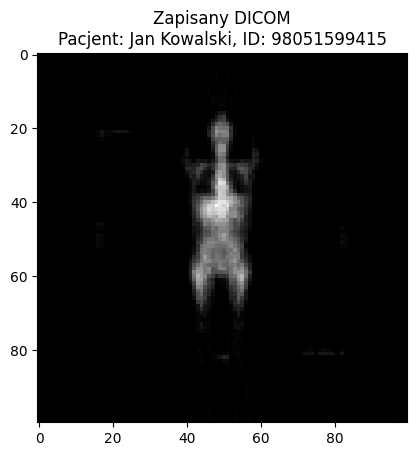

In [9]:
dane_pacjenta = ("Jan", "Kowalski", "98051599415")
data_badania = datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")
nazwa_pliku = f"dicom/rekonstrukcja_{dane_pacjenta[0]}_{dane_pacjenta[1]}_{data_badania.replace(':', '-')}.dcm"
komentarz = "Rekonstrukcja tomograficzna z filtrowaniem"

utils.zapisz_dicom(rekonstruowany_obraz_filtrowany, nazwa_pliku, dane_pacjenta, data_badania, komentarz)